In [5]:
import requests, re, time
import pandas as pd

BASE = "https://rest.uniprot.org/uniprotkb/search"


In [6]:
def fetch_uniprot(query, fields="accession,sequence,length", max_records=3000):
    params = {"query": query, "format": "tsv", "fields": fields, "size": 500}
    url, rows, first = BASE, [], True
    while url and len(rows) < max_records:
        r = requests.get(url, params=params if first else None, timeout=60)
        r.raise_for_status()
        first = False
        lines = r.text.strip().split("\n")
        header, data = lines[0].split("\t"), lines[1:]
        rows += [dict(zip(header, ln.split("\t"))) for ln in data if ln]
        m = re.search(r'<([^>]+)>;\s*rel="next"', r.headers.get("Link", ""))
        url = m.group(1) if m else None
        time.sleep(0.3)
    df = pd.DataFrame(rows[:max_records])
    df.columns = df.columns.str.lower()
    return df


In [ ]:
import gzip, base64, hashlib, io
import pandas as pd

PUBLISHED_MD5 = "0c1ce4da5e0b8282b883436ec33fb8c6"
REBUILD_FROM_UNIPROT = False

_BENCHMARK_B64 = """
...
3qWa/H9ANyCn5tsAAA==
"""

_raw = gzip.decompress(base64.b64decode("".join(_BENCHMARK_B64.split())))
_md5 = hashlib.md5(_raw).hexdigest()
assert _md5 == PUBLISHED_MD5, f"embedded benchmark is corrupted: {_md5}"

with open("amp_dataset.csv", "wb") as _f:
    _f.write(_raw)
data = pd.read_csv(io.BytesIO(_raw))

print(f"Published benchmark loaded from the notebook itself: {len(data)} peptides "
      f"({int(data.label.sum())} AMP / {int((1 - data.label).sum())} non-AMP)")
print(f"checksum {_md5} verified - every number below reproduces the paper")
print("amp_dataset.csv written for the cells that follow; nothing was downloaded.")
print("Set REBUILD_FROM_UNIPROT = True to rebuild from the live API instead,")
print("but note that Swiss-Prot keeps growing, so a rebuild will not match the paper.")


Published benchmark loaded from the notebook itself: 1724 peptides (862 AMP / 862 non-AMP)
checksum 0c1ce4da5e0b8282b883436ec33fb8c6 verified - every number below reproduces the paper
amp_dataset.csv written for the cells that follow; nothing was downloaded.
Set REBUILD_FROM_UNIPROT = True to rebuild from the live API instead,
but note that Swiss-Prot keeps growing, so a rebuild will not match the paper.


In [7]:
if REBUILD_FROM_UNIPROT:
    pos = fetch_uniprot(
        "reviewed:true AND keyword:KW-0929 AND length:[10 TO 50] NOT fragment:true",
        max_records=3000)
    pos["label"] = 1

    neg = fetch_uniprot(
        "reviewed:true AND length:[10 TO 50] NOT keyword:KW-0929 NOT fragment:true",
        max_records=3000)
    neg["label"] = 0

    print("raw positives:", len(pos), "| raw negatives:", len(neg))
    print("columns:", pos.columns.tolist())


In [8]:
if REBUILD_FROM_UNIPROT:
    STANDARD = set("ACDEFGHIKLMNPQRSTVWY")

    def clean(df):
        df = df.copy()
        df["sequence"] = df["sequence"].str.upper().str.strip()
        df = df[df["sequence"].apply(lambda s: set(s) <= STANDARD)]
        df = df[df["sequence"].str.len().between(10, 50)]
        df = df.drop_duplicates(subset="sequence")
        return df[["sequence", "label"]]

    pos_c, neg_c = clean(pos), clean(neg)

    overlap = set(pos_c.sequence) & set(neg_c.sequence)
    pos_c = pos_c[~pos_c.sequence.isin(overlap)]
    neg_c = neg_c[~neg_c.sequence.isin(overlap)]

    n = min(len(pos_c), len(neg_c))
    data = (pd.concat([pos_c.sample(n, random_state=42),
                       neg_c.sample(n, random_state=42)])
              .sample(frac=1, random_state=42)
              .reset_index(drop=True))

    data.to_csv("amp_dataset.csv", index=False)
    print("cleaned & balanced:", data.shape)
    print(data.label.value_counts().to_dict())
    data.head()


            mean   min   max
label                       
0      32.281903  10.0  50.0
1      27.006961  10.0  50.0


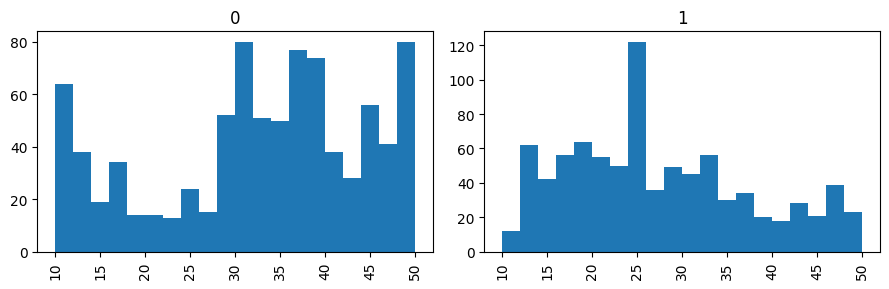

In [9]:
import matplotlib.pyplot as plt
data["len"] = data.sequence.str.len()
print(data.groupby("label")["len"].describe()[["mean", "min", "max"]])
data["len"].hist(by=data["label"], bins=20, figsize=(9, 3))
plt.tight_layout(); plt.show()


In [12]:
import math, numpy as np, pandas as pd

AA = "ACDEFGHIKLMNPQRSTVWY"
KD  = {"A":1.8,"R":-4.5,"N":-3.5,"D":-3.5,"C":2.5,"Q":-3.5,"E":-3.5,"G":-0.4,
       "H":-3.2,"I":4.5,"L":3.8,"K":-3.9,"M":1.9,"F":2.8,"P":-1.6,"S":-0.8,
       "T":-0.7,"W":-0.9,"Y":-1.3,"V":4.2}
EIS = {"A":0.62,"R":-2.53,"N":-0.78,"D":-0.90,"C":0.29,"Q":-0.85,"E":-0.74,
       "G":0.48,"H":-0.40,"I":1.38,"L":1.06,"K":-1.50,"M":0.64,"F":1.19,
       "P":0.12,"S":-0.18,"T":-0.05,"W":0.81,"Y":0.26,"V":1.08}
PKA = {"D":3.65,"E":4.25,"C":8.33,"Y":10.07,"H":6.00,"K":10.53,"R":12.48}

def net_charge(seq, pH=7.0):
    pos = 1/(1+10**(pH-8.6)); neg = 1/(1+10**(3.6-pH))
    for a in seq:
        if a in "KRH":   pos += 1/(1+10**(pH-PKA[a]))
        elif a in "DECY": neg += 1/(1+10**(PKA[a]-pH))
    return pos - neg

def gravy(seq):       return sum(KD[a] for a in seq)/len(seq)
def aromaticity(seq): return sum(a in "FWY" for a in seq)/len(seq)
def frac_pos(seq):    return sum(a in "KR"  for a in seq)/len(seq)

def hydrophobic_moment(seq, angle=100):
    rad = math.radians(angle)
    s = sum(EIS[a]*math.sin(i*rad) for i,a in enumerate(seq))
    c = sum(EIS[a]*math.cos(i*rad) for i,a in enumerate(seq))
    return math.sqrt(s*s + c*c)/len(seq)

def aac(seq):  return [seq.count(a)/len(seq) for a in AA]


In [13]:
def featurize(seq):
    seq = str(seq).upper()
    return aac(seq) + [len(seq), net_charge(seq), gravy(seq),
                       hydrophobic_moment(seq), aromaticity(seq), frac_pos(seq)]

NAMES = [f"AAC_{a}" for a in AA] + ["length","net_charge","gravy",
         "hydrophobic_moment","aromaticity","frac_positive"]

df = pd.read_csv("amp_dataset.csv")
X = np.array([featurize(s) for s in df.sequence])
y = df.label.values
print("X:", X.shape, "| y:", y.shape)

feat = pd.DataFrame(X, columns=NAMES)
feat.head()


X: (1724, 26) | y: (1724,)


,AAC_A,AAC_C,AAC_D,AAC_E,AAC_F,AAC_G,AAC_H,AAC_I,AAC_K,AAC_L,...,AAC_T,AAC_V,AAC_W,AAC_Y,length,net_charge,gravy,hydrophobic_moment,aromaticity,frac_positive
0,0.083333,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.166667,0.000000,0.083333,...,0.000000,0.083333,0.000000,0.166667,12.0,0.884823,1.125000,0.322098,0.166667,0.083333
1,0.000000,0.081081,0.000000,0.054054,0.000000,0.054054,0.027027,0.081081,0.270270,0.000000,...,0.000000,0.135135,0.000000,0.000000,37.0,9.933346,-0.791892,0.177260,0.000000,0.324324
2,0.125000,0.083333,0.000000,0.000000,0.041667,0.041667,0.000000,0.041667,0.125000,0.208333,...,0.041667,0.083333,0.000000,0.000000,24.0,2.885642,1.337500,0.274575,0.041667,0.125000
3,0.034483,0.206897,0.000000,0.034483,0.034483,0.103448,0.000000,0.034483,0.034483,0.000000,...,0.103448,0.068966,0.034483,0.034483,29.0,0.708420,0.086207,0.098164,0.103448,0.068966
4,0.076923,0.000000,0.076923,0.000000,0.000000,0.153846,0.025641,0.076923,0.102564,0.000000,...,0.025641,0.076923,0.051282,0.025641,39.0,4.066103,-0.841026,0.178654,0.076923,0.179487


       net_charge  hydrophobic_moment  gravy  frac_positive
label                                                      
0           2.768               0.165 -0.116          0.145
1           2.886               0.289  0.339          0.152


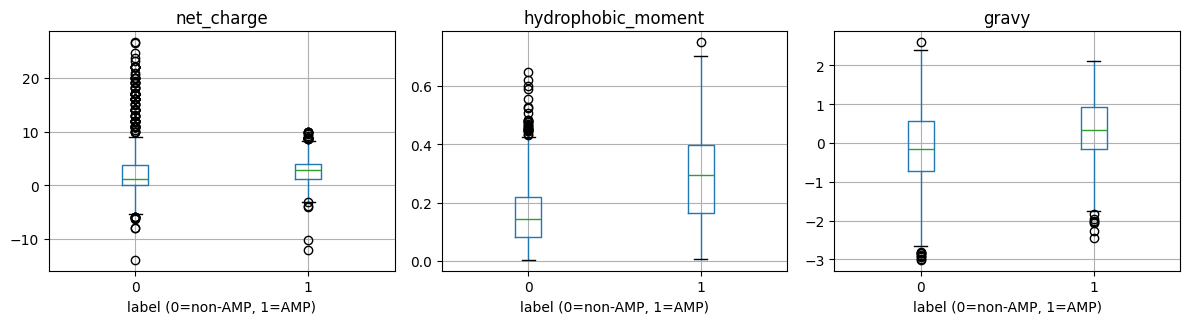

In [14]:
import matplotlib.pyplot as plt
chk = feat.copy(); chk["label"] = y
print(chk.groupby("label")[["net_charge","hydrophobic_moment","gravy","frac_positive"]].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, ["net_charge","hydrophobic_moment","gravy"]):
    chk.boxplot(column=col, by="label", ax=ax); ax.set_title(col); ax.set_xlabel("label (0=non-AMP, 1=AMP)")
plt.suptitle(""); plt.tight_layout(); plt.show()


In [15]:
import warnings; warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Reg.":  LogisticRegression(max_iter=2000),
    "Random Forest":  RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0),
    "Grad. Boosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, random_state=0),
    "SVM (RBF)":      SVC(probability=True, random_state=0),
}

cv = StratifiedKFold(5, shuffle=True, random_state=1)
print("5-fold CV ROC-AUC:")
scores = {}
for name, m in models.items():
    pipe = Pipeline([("scale", StandardScaler()), ("clf", m)])
    sc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    scores[name] = sc.mean()
    print(f"  {name:16s} {sc.mean():.3f} ± {sc.std():.3f}")

best_name = max(scores, key=scores.get)
print("\nBest model:", best_name)


5-fold CV ROC-AUC:
  Logistic Reg.    0.866 ± 0.013
  Random Forest    0.962 ± 0.010
  Grad. Boosting   0.959 ± 0.009
  SVM (RBF)        0.945 ± 0.010

Best model: Random Forest


Random Forest — held-out test:
  AUC=0.969  acc=0.919  F1=0.917  prec=0.937  rec=0.898


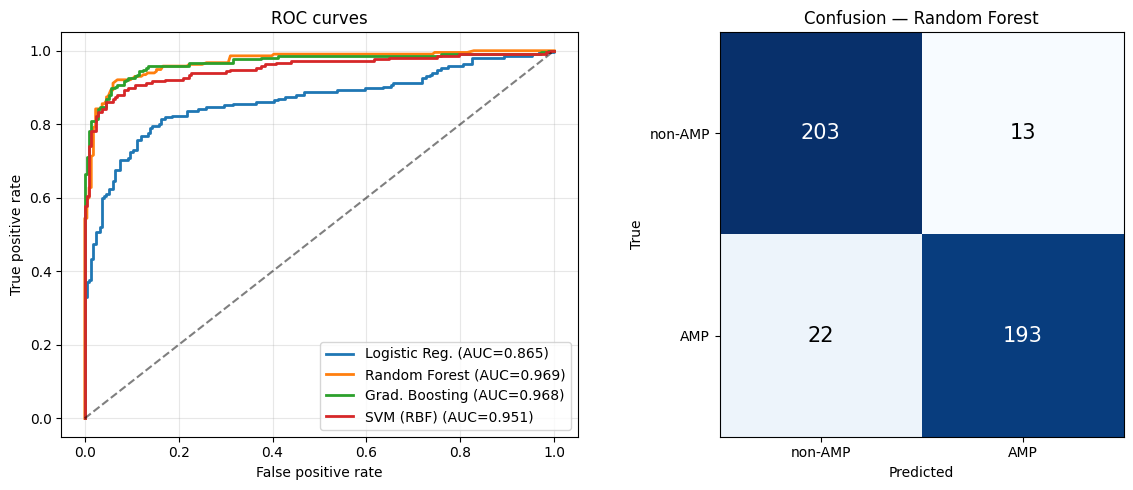

In [17]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score, f1_score,
                             precision_score, recall_score, confusion_matrix)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for name, m in models.items():
    p = Pipeline([("s", StandardScaler()), ("c", m)]).fit(Xtr, ytr)
    pr = p.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, pr)
    ax1.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(yte, pr):.3f})")
ax1.plot([0, 1], [0, 1], "k--", alpha=.5)
ax1.set_xlabel("False positive rate"); ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curves"); ax1.legend(loc="lower right"); ax1.grid(alpha=.3)

best = Pipeline([("s", StandardScaler()), ("c", models[best_name])]).fit(Xtr, ytr)
pr = best.predict_proba(Xte)[:, 1]; pred = (pr > 0.5).astype(int)
print(f"{best_name} — held-out test:")
print(f"  AUC={roc_auc_score(yte,pr):.3f}  acc={accuracy_score(yte,pred):.3f}  "
      f"F1={f1_score(yte,pred):.3f}  prec={precision_score(yte,pred):.3f}  rec={recall_score(yte,pred):.3f}")

cm = confusion_matrix(yte, pred)
im = ax2.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax2.text(j, i, str(v), ha="center", va="center",
             color="white" if v > cm.max()/2 else "black", fontsize=15)
ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
ax2.set_xticklabels(["non-AMP","AMP"]); ax2.set_yticklabels(["non-AMP","AMP"])
ax2.set_xlabel("Predicted"); ax2.set_ylabel("True"); ax2.set_title(f"Confusion — {best_name}")
plt.tight_layout(); plt.show()


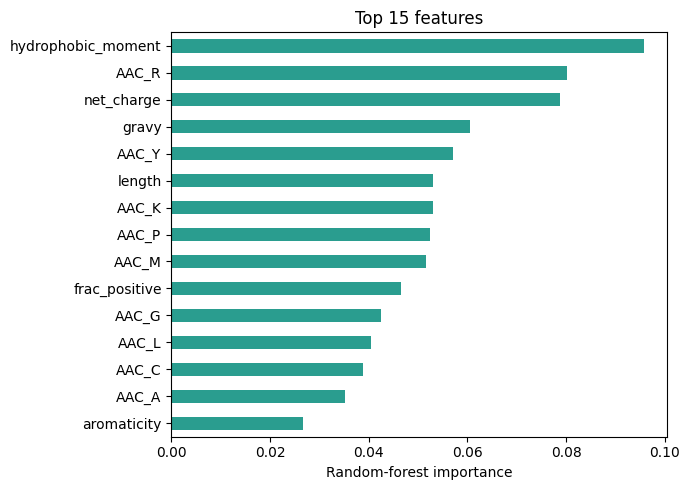

In [18]:
rf = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=0)
rf.fit(StandardScaler().fit_transform(X), y)
imp = pd.Series(rf.feature_importances_, index=NAMES).sort_values()[-15:]

plt.figure(figsize=(7, 5))
imp.plot.barh(color="#2a9d8f")
plt.xlabel("Random-forest importance")
plt.title("Top 15 features")
plt.tight_layout(); plt.show()


In [37]:
!pip install -q transformers
import torch, numpy as np
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

MODEL = "facebook/esm2_t30_150M_UR50D"   #   (480-d). : esm2_t30_150M_UR50D
tok   = AutoTokenizer.from_pretrained(MODEL)
esm   = AutoModel.from_pretrained(MODEL).to(device).eval()
print("loaded:", MODEL)
import transformers, sklearn, numpy
print(f"environment: torch {torch.__version__} | transformers {transformers.__version__}"
      f" | scikit-learn {sklearn.__version__} | numpy {numpy.__version__}")
print("Note: ESM-2 values in the paper came from an earlier transformers release;")
print("newer releases shift mean-pooled last_hidden_state and raise the ESM probe")
print("R-squared by up to 0.023. Layer-wise and non-ESM results are unaffected.")


device: cuda


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


loaded: facebook/esm2_t30_150M_UR50D


In [38]:
def embed(seqs, batch_size=32, max_len=60):
    out_all = []
    for i in range(0, len(seqs), batch_size):
        batch = [str(s).upper() for s in seqs[i:i+batch_size]]
        enc = tok(batch, return_tensors="pt", padding=True,
                  truncation=True, max_length=max_len)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            h = esm(**enc).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1)
        mean = (h * mask).sum(1) / mask.sum(1).clamp(min=1)
        out_all.append(mean.cpu().numpy())
        if (i // batch_size) % 10 == 0:
            print(f"  embedded {i+len(batch)}/{len(seqs)}")
    return np.vstack(out_all)


In [22]:
X_esm = embed(df.sequence.tolist())
print("X_esm:", X_esm.shape)


  embedded 32/1724
  embedded 352/1724
  embedded 672/1724
  embedded 992/1724
  embedded 1312/1724
  embedded 1632/1724
X_esm: (1724, 480)


In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(5, shuffle=True, random_state=1)

def evaluate(features, name):
    for clf, cname in [(LogisticRegression(max_iter=3000), "LogReg"),
                       (RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                               random_state=0), "RandForest")]:
        pipe = Pipeline([("s", StandardScaler()), ("c", clf)])
        auc = cross_val_score(pipe, features, y, cv=cv, scoring="roc_auc", n_jobs=-1)
        print(f"  {name:18s} + {cname:11s}  AUC = {auc.mean():.3f} ± {auc.std():.3f}")

print("Comparison (5-fold CV ROC-AUC):")
evaluate(X,      "Handcrafted (26)")
evaluate(X_esm,  "ESM-2 (480)")
evaluate(np.hstack([X, X_esm]), "Combined")


Comparison (5-fold CV ROC-AUC):
  Handcrafted (26)   + LogReg       AUC = 0.866 ± 0.013
  Handcrafted (26)   + RandForest   AUC = 0.962 ± 0.010
  ESM-2 (480)        + LogReg       AUC = 0.948 ± 0.007
  ESM-2 (480)        + RandForest   AUC = 0.960 ± 0.009
  Combined           + LogReg       AUC = 0.947 ± 0.007
  Combined           + RandForest   AUC = 0.960 ± 0.008


In [39]:
HB_D = {"A":0,"R":5,"N":2,"D":0,"C":1,"Q":2,"E":0,"G":0,"H":1,"I":0,
        "L":0,"K":3,"M":0,"F":0,"P":0,"S":1,"T":1,"W":1,"Y":1,"V":0}
HB_A = {"A":0,"R":0,"N":1,"D":2,"C":0,"Q":1,"E":2,"G":0,"H":1,"I":0,
        "L":0,"K":0,"M":0,"F":0,"P":0,"S":1,"T":1,"W":0,"Y":1,"V":0}

WW_IF  = {"A":0.17,"R":0.81,"N":0.42,"D":1.23,"C":-0.24,"Q":0.58,"E":2.02,"G":0.01,
          "H":0.17,"I":-0.31,"L":-0.56,"K":0.99,"M":-0.23,"F":-1.13,"P":0.45,
          "S":0.13,"T":0.14,"W":-1.85,"Y":-0.94,"V":0.07}
WW_OCT = {"A":0.50,"R":1.81,"N":0.85,"D":3.64,"C":-0.02,"Q":0.77,"E":3.63,"G":1.15,
          "H":0.11,"I":-1.12,"L":-1.25,"K":2.80,"M":-0.67,"F":-1.71,"P":0.14,
          "S":0.46,"T":0.25,"W":-2.09,"Y":-0.71,"V":-0.46}

VOL = {"A":88.6,"R":173.4,"N":114.1,"D":111.1,"C":108.5,"Q":143.8,"E":138.4,"G":60.1,
       "H":153.2,"I":166.7,"L":166.7,"K":168.6,"M":162.9,"F":189.9,"P":112.7,
       "S":89.0,"T":116.1,"W":227.8,"Y":193.6,"V":140.0}
AROM, CATION, CHARGED = set("FWY"), set("KR"), set("DEKRH")


In [40]:
def featurize_interactions(s):
    s = str(s).upper(); L = len(s)
    hb_d = sum(HB_D[a] for a in s); hb_a = sum(HB_A[a] for a in s)
    wif  = sum(WW_IF[a]  for a in s)/L
    woct = sum(WW_OCT[a] for a in s)/L
    vol  = sum(VOL[a]    for a in s)/L
    charged = sum(a in CHARGED for a in s)/L
    arom    = sum(a in AROM   for a in s)/L
    fpos    = sum(a in CATION for a in s)/L
    return [hb_d/L, hb_a/L, (hb_d+hb_a)/L,
            wif, woct, woct - wif,
            vol, charged, arom*fpos]

NEW_NAMES = ["hb_donor_dens","hb_acc_dens","hb_total_dens",
             "ww_interface","ww_octanol","ww_oct_minus_if",
             "mean_volume","charged_frac","cation_pi"]

X_new  = np.array([featurize_interactions(s) for s in df.sequence])
X_full = np.hstack([X, X_new])
print("full feature matrix:", X_full.shape)


full feature matrix: (1724, 35)


In [41]:
def evaluate(features, name):
    for clf, cn in [(LogisticRegression(max_iter=3000), "LogReg"),
                    (RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0), "RF")]:
        auc = cross_val_score(Pipeline([("s", StandardScaler()), ("c", clf)]),
                              features, y, cv=cv, scoring="roc_auc", n_jobs=-1)
        print(f"  {name:24s}+{cn:8s} AUC={auc.mean():.3f}±{auc.std():.3f}")

print("5-fold CV ROC-AUC:")
evaluate(X,      "Base (26)")
evaluate(X_new,  "NonCovalent only (9)")
evaluate(X_full, "Base+NonCovalent (35)")

nf = pd.DataFrame(X_new, columns=NEW_NAMES); nf["label"] = y
print("\nMeans by class:\n", nf.groupby("label").mean().round(3).T)


5-fold CV ROC-AUC:
  Base (26)               +LogReg   AUC=0.866±0.016
  Base (26)               +RF       AUC=0.963±0.004
  NonCovalent only (9)    +LogReg   AUC=0.773±0.018
  NonCovalent only (9)    +RF       AUC=0.890±0.003
  Base+NonCovalent (35)   +LogReg   AUC=0.873±0.016
  Base+NonCovalent (35)   +RF       AUC=0.962±0.006

Means by class:
 label                  0        1
hb_donor_dens      0.965    0.809
hb_acc_dens        0.349    0.252
hb_total_dens      1.314    1.060
ww_interface       0.132    0.091
ww_octanol         0.457    0.401
ww_oct_minus_if    0.325    0.310
mean_volume      134.168  133.118
charged_frac       0.228    0.211
cation_pi          0.011    0.011


In [42]:
!apt-get -qq install -y cd-hit


In [43]:
import subprocess, re

with open("seqs.fasta", "w") as f:
    for i, s in enumerate(df.sequence):
        f.write(f">{i}\n{s}\n")

subprocess.run("cd-hit -i seqs.fasta -o clust -c 0.4 -n 2 -l 5 -M 0 -T 0",
               shell=True, check=True, capture_output=True)

cluster_of = {}
cid = -1
for line in open("clust.clstr"):
    if line.startswith(">Cluster"):
        cid = int(line.split()[1])
    else:
        m = re.search(r">(\d+)\.\.\.", line)
        if m:
            cluster_of[int(m.group(1))] = cid

missing = [i for i in range(len(df)) if i not in cluster_of]
nxt = (max(cluster_of.values()) + 1) if cluster_of else 0
for i in missing:
    cluster_of[i] = nxt; nxt += 1
if missing:
    print("note: assigned singleton clusters to", len(missing), "sequences")

groups = np.array([cluster_of[i] for i in range(len(df))])
print("sequences:", len(df), "| clusters:", len(set(groups)))

PUBLISHED_CLUSTERS = 351
if len(set(groups)) == PUBLISHED_CLUSTERS:
    print(f"cluster count matches the paper ({PUBLISHED_CLUSTERS}).")
else:
    print(f"NOTE: {len(set(groups))} clusters here, the paper reports {PUBLISHED_CLUSTERS}.")
    print("      cd-hit version differences can shift this; the homology-aware")
    print("      numbers below may then differ from the published ones.")


sequences: 1724 | clusters: 351


In [44]:
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

rf = lambda: Pipeline([("s", StandardScaler()),
                       ("c", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0))])

auc_rand = cross_val_score(rf(), X_full, y,
                           cv=StratifiedKFold(5, shuffle=True, random_state=1),
                           scoring="roc_auc", n_jobs=-1)

auc_grp = cross_val_score(rf(), X_full, y, groups=groups,
                          cv=GroupKFold(5), scoring="roc_auc", n_jobs=-1)

print(f"Random split   AUC = {auc_rand.mean():.3f} ± {auc_rand.std():.3f}")
print(f"Homology split AUC = {auc_grp.mean():.3f} ± {auc_grp.std():.3f}")
print(f"==> Leakage gap = {auc_rand.mean()-auc_grp.mean():.3f}")


Random split   AUC = 0.962 ± 0.010
Homology split AUC = 0.934 ± 0.014
==> Leakage gap = 0.027


In [46]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold

def targets(s):
    s = str(s).upper(); L = len(s)
    arom = sum(a in AROM for a in s)/L; fpos = sum(a in CATION for a in s)/L
    return {
        "net_charge":          net_charge(s),
        "hydrophobic_moment":  muh(s) if 'muh' in globals() else hydrophobic_moment(s),
        "gravy":               sum(KD[a] for a in s)/L,
        "ww_interface":        sum(WW_IF[a] for a in s)/L,
        "ww_octanol":          sum(WW_OCT[a] for a in s)/L,
        "hb_donor_dens":       sum(HB_D[a] for a in s)/L,
        "hb_acc_dens":         sum(HB_A[a] for a in s)/L,
        "cation_pi":           arom*fpos,
        "mean_volume":         sum(VOL[a] for a in s)/L,
        "charged_frac":        sum(a in CHARGED for a in s)/L,
    }

T = pd.DataFrame([targets(s) for s in df.sequence])

X_aac = np.array([[str(s).upper().count(a)/len(str(s)) for a in AA] for s in df.sequence])
print("targets:", T.shape, "| AAC baseline:", X_aac.shape, "| ESM:", X_esm.shape)


targets: (1724, 10) | AAC baseline: (1724, 20) | ESM: (1724, 480)


          property  R2_ESM  R2_AAC  ESM_minus_AAC
        net_charge   0.958   0.865          0.093
hydrophobic_moment   0.720   0.330          0.389
             gravy   0.988   1.000         -0.012
      ww_interface   0.977   1.000         -0.023
        ww_octanol   0.984   1.000         -0.016
     hb_donor_dens   0.990   1.000         -0.010
       hb_acc_dens   0.978   1.000         -0.022
         cation_pi   0.760   0.712          0.048
       mean_volume   0.976   1.000         -0.024
      charged_frac   0.981   1.000         -0.019


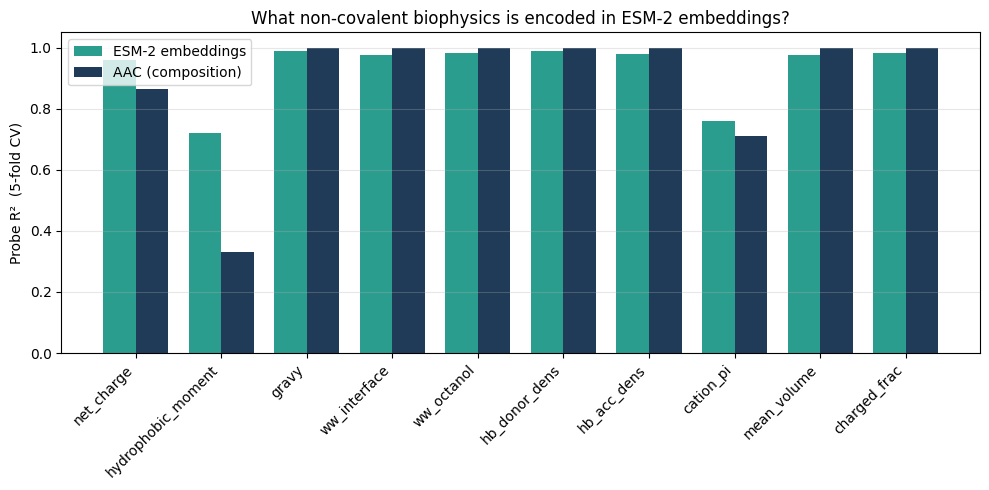

In [47]:
import matplotlib.pyplot as plt
cv = KFold(5, shuffle=True, random_state=1)

def probe_r2(features, target):
    m = Pipeline([("s", StandardScaler()), ("r", RidgeCV(alphas=np.logspace(-2, 4, 10)))])
    return cross_val_score(m, features, target, cv=cv, scoring="r2", n_jobs=-1).mean()

rows = []
for col in T.columns:
    r2_esm = probe_r2(X_esm,  T[col].values)
    r2_aac = probe_r2(X_aac,  T[col].values)
    rows.append((col, r2_esm, r2_aac, r2_esm - r2_aac))
res = pd.DataFrame(rows, columns=["property", "R2_ESM", "R2_AAC", "ESM_minus_AAC"])
print(res.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(res)); w = 0.38
ax.bar(x - w/2, res.R2_ESM, w, label="ESM-2 embeddings", color="#2a9d8f")
ax.bar(x + w/2, res.R2_AAC, w, label="AAC (composition)", color="#1f3b57")
ax.set_xticks(x); ax.set_xticklabels(res.property, rotation=45, ha="right")
ax.set_ylabel("Probe R²  (5-fold CV)"); ax.set_ylim(0, 1.05)
ax.set_title("What non-covalent biophysics is encoded in ESM-2 embeddings?")
ax.legend(); ax.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()


In [48]:
def embed_layers(seqs, batch_size=32, max_len=60):
    nlayers = esm.config.num_hidden_layers + 1
    acc = [[] for _ in range(nlayers)]
    for i in range(0, len(seqs), batch_size):
        batch = [str(s).upper() for s in seqs[i:i+batch_size]]
        enc = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_len)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = esm(**enc, output_hidden_states=True)
        mask = enc["attention_mask"].unsqueeze(-1)
        for L, h in enumerate(out.hidden_states):
            pooled = (h * mask).sum(1) / mask.sum(1).clamp(min=1)
            acc[L].append(pooled.cpu().numpy())
        if (i // batch_size) % 10 == 0: print(f"  {i+len(batch)}/{len(seqs)}")
    return [np.vstack(a) for a in acc]

layer_emb = embed_layers(df.sequence.tolist())
print("layers:", len(layer_emb), "| each:", layer_emb[0].shape)


  32/1724
  352/1724
  672/1724
  992/1724
  1312/1724
  1632/1724
layers: 31 | each: (1724, 640)


layer  0: R2=0.486
layer  1: R2=0.620
layer  2: R2=0.681
layer  3: R2=0.726
layer  4: R2=0.732
layer  5: R2=0.764
layer  6: R2=0.766
layer  7: R2=0.760
layer  8: R2=0.762
layer  9: R2=0.761
layer 10: R2=0.746
layer 11: R2=0.749
layer 12: R2=0.728
layer 13: R2=0.743
layer 14: R2=0.735
layer 15: R2=0.723
layer 16: R2=0.714
layer 17: R2=0.716
layer 18: R2=0.704
layer 19: R2=0.708
layer 20: R2=0.719
layer 21: R2=0.713
layer 22: R2=0.719
layer 23: R2=0.710
layer 24: R2=0.706
layer 25: R2=0.712
layer 26: R2=0.715
layer 27: R2=0.729
layer 28: R2=0.742
layer 29: R2=0.742
layer 30: R2=0.726


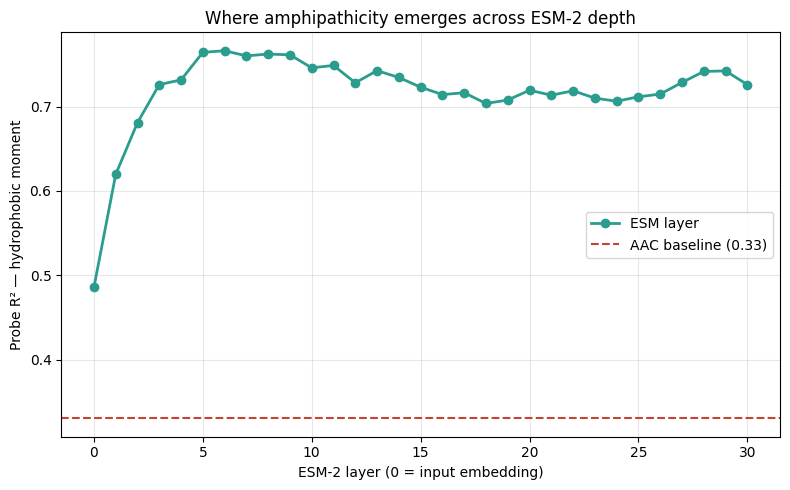

In [49]:
prop = T["hydrophobic_moment"].values
r2_by_layer = [probe_r2(emb, prop) for emb in layer_emb]
for L, r in enumerate(r2_by_layer): print(f"layer {L:2d}: R2={r:.3f}")

r2_aac = probe_r2(X_aac, prop)

plt.figure(figsize=(8, 5))
plt.plot(range(len(r2_by_layer)), r2_by_layer, "o-", color="#2a9d8f", lw=2, label="ESM layer")
plt.axhline(r2_aac, ls="--", color="#c1452f", label=f"AAC baseline ({r2_aac:.2f})")
plt.xlabel("ESM-2 layer (0 = input embedding)")
plt.ylabel("Probe R² — hydrophobic moment")
plt.title("Where amphipathicity emerges across ESM-2 depth")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
rng = np.random.default_rng(7)

oracle = Pipeline([("s", StandardScaler()),
                   ("c", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0))]).fit(X_full, y)

def feats(s):  return np.array(featurize(s) + featurize_interactions(s))
def amp_prob(seqs): return oracle.predict_proba(np.vstack([feats(s) for s in seqs]))[:, 1]

def kmers(s, k=3): return {s[i:i+k] for i in range(len(s)-k+1)}
train_kmers = [kmers(s) for s in df.sequence]
def novelty(s):
    ks = kmers(s)
    return 1 - max((len(ks & t)/len(ks | t)) for t in train_kmers) if ks else 1.0

def fitness(seqs):
    p = amp_prob(seqs)
    mh = np.array([min(hydrophobic_moment(s)/0.4, 1.0) for s in seqs])
    return 0.8*p + 0.2*mh


In [52]:
AA = "ACDEFGHIKLMNPQRSTVWY"
def mutate(s):
    s = list(s); r = rng.random()
    if r < 0.7 and s:                 s[rng.integers(len(s))] = AA[rng.integers(20)]
    elif r < 0.85 and len(s) < 50:    s.insert(rng.integers(len(s)+1), AA[rng.integers(20)])
    elif len(s) > 10:                 del s[rng.integers(len(s))]
    return "".join(s)
def crossover(a, b):
    if len(a) < 2 or len(b) < 2: return a
    c = a[:rng.integers(1, len(a))] + b[rng.integers(1, len(b)):]
    return c[:50] if len(c) > 50 else (c if len(c) >= 10 else a)

amp_seqs = df[df.label == 1].sequence.tolist()
pop = [mutate(mutate(rng.choice(amp_seqs))) for _ in range(200)]
best_hist = []
for gen in range(15):
    fit = fitness(pop); order = np.argsort(fit)[::-1]
    elite = [pop[i] for i in order[:50]]; best_hist.append(float(fit[order[0]]))
    children = []
    while len(children) < 150:
        a, b = rng.choice(len(elite), 2, replace=False)
        c = crossover(elite[a], elite[b])
        if rng.random() < 0.8: c = mutate(c)
        if 10 <= len(c) <= 50: children.append(c)
    pop = elite + children
print("best fitness/gen:", [round(x,3) for x in best_hist])


best fitness/gen: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


novel high-confidence designs: 116
                        sequence  amp_prob  net_charge   uH  novelty  len
        GLLDFIKAAGKGLVNVGKGLVNVT     1.000         2.0 0.50     0.61   24
          GLLKNVLGQIKAGAGHIANAMK     1.000         3.1 0.40     0.89   22
           GLKNVLGQLKAGAGHIANAMK     1.000         3.1 0.41     0.89   21
         LIKGLVSKGFKTALDFIKAAGGC     1.000         2.9 0.40     0.84   23
LIKGSVSKGFKTALDFIKALKAGAGHIANAMK     0.997         5.1 0.42     0.89   32
         FLPAIHGAAAKFLKIFAVISKKG     0.997         4.1 0.41     0.60   23
         GLLDFINAAGKGLKIFAVISKKC     0.997         2.9 0.41     0.76   23
    WLGGAAKIGKNVLGPLKAAGKGLVNVVT     0.997         4.0 0.44     0.79   28
         FLPAIHGAAAKFLKIFAVISKKC     0.997         4.0 0.40     0.55   23
        LIKGLVSKGFKTALDFIKAAGRGC     0.997         3.9 0.52     0.84   24


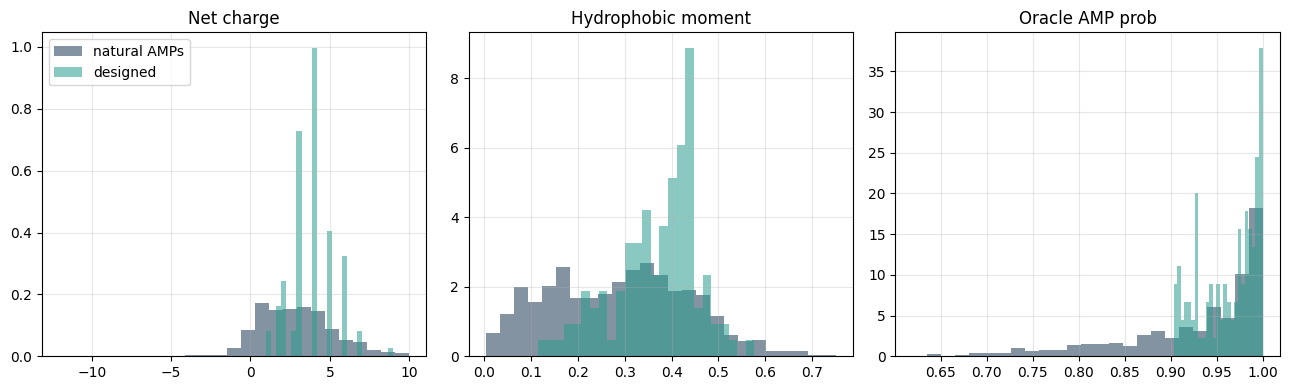

In [53]:
import matplotlib.pyplot as plt
fit = fitness(pop); order = np.argsort(fit)[::-1]
designs, seen = [], set()
for i in order:
    s = pop[i]
    if s in seen: continue
    seen.add(s)
    if novelty(s) > 0.5 and amp_prob([s])[0] > 0.9: designs.append(s)
print("novel high-confidence designs:", len(designs))

tbl = pd.DataFrame([{"sequence": s, "amp_prob": round(float(amp_prob([s])[0]),3),
                     "net_charge": round(net_charge(s),1), "uH": round(hydrophobic_moment(s),2),
                     "novelty": round(novelty(s),2), "len": len(s)} for s in designs[:10]])
print(tbl.to_string(index=False)); tbl.to_csv("designed_peptides.csv", index=False)

nat = df[df.label==1].sequence.tolist()
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a,(fn,t) in zip(ax, [(lambda S:[net_charge(x) for x in S],"Net charge"),
                         (lambda S:[hydrophobic_moment(x) for x in S],"Hydrophobic moment"),
                         (lambda S:amp_prob(S),"Oracle AMP prob")]):
    a.hist(fn(nat), bins=25, alpha=.55, label="natural AMPs", color="#1f3b57", density=True)
    a.hist(fn(designs), bins=25, alpha=.55, label="designed", color="#2a9d8f", density=True)
    a.set_title(t); a.grid(alpha=.3)
ax[0].legend(); plt.tight_layout(); plt.show()


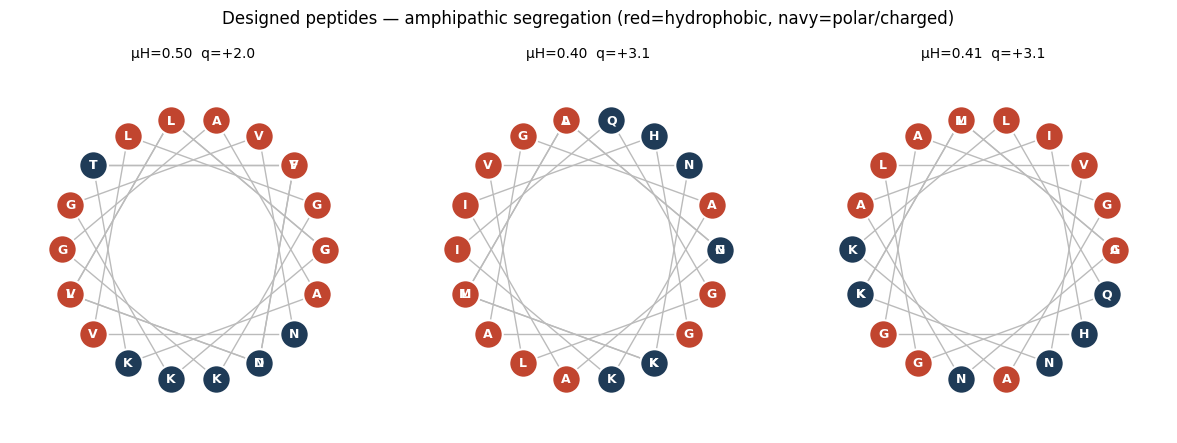

In [54]:
import math
def helical_wheel(seq, ax, title=""):
    seq = str(seq).upper()
    for i, a in enumerate(seq):
        ang = math.radians(100*i); x, y = math.cos(ang), math.sin(ang)
        col = "#c1452f" if EIS[a] > 0 else "#1f3b57"
        ax.scatter(x, y, s=420, color=col, zorder=3, edgecolor="white", linewidth=1.5)
        ax.text(x, y, a, ha="center", va="center", color="white", fontsize=9, zorder=4, fontweight="bold")
        if i: pa = math.radians(100*(i-1)); ax.plot([math.cos(pa),x],[math.sin(pa),y], color="#bbb", lw=1, zorder=1)
    ax.set_xlim(-1.4,1.4); ax.set_ylim(-1.4,1.4); ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.3))
for ax, s in zip(axes, designs[:3]):
    helical_wheel(s, ax, f"μH={hydrophobic_moment(s):.2f}  q={net_charge(s):+.1f}")
fig.suptitle("Designed peptides — amphipathic segregation (red=hydrophobic, navy=polar/charged)", y=1.02)
plt.tight_layout(); plt.show()


In [55]:
X_esm_train = embed(df.sequence.tolist())
esm_oracle = Pipeline([("s", StandardScaler()),
                       ("c", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0))]).fit(X_esm_train, y)
p_esm  = esm_oracle.predict_proba(embed(designs))[:, 1]
p_desc = amp_prob(designs)
print(f"corr(descriptor-oracle, ESM-oracle) on designs: {np.corrcoef(p_desc, p_esm)[0,1]:.3f}")
print(f"designs rated >0.8 by BOTH oracles: {int(((p_desc>0.8)&(p_esm>0.8)).sum())}/{len(designs)}")


  embedded 32/1724
  embedded 352/1724
  embedded 672/1724
  embedded 992/1724
  embedded 1312/1724
  embedded 1632/1724
  embedded 32/116
corr(descriptor-oracle, ESM-oracle) on designs: 0.145
designs rated >0.8 by BOTH oracles: 83/116


In [58]:
def amp_prob_esm(seqs):
    return esm_oracle.predict_proba(embed(list(seqs)))[:, 1]

def fitness_multi(seqs):
    p1 = amp_prob(seqs)
    p2 = amp_prob_esm(seqs)
    mh = np.array([min(hydrophobic_moment(s)/0.4, 1.0) for s in seqs])
    return 0.5*np.minimum(p1, p2) + 0.3*((p1 + p2)/2) + 0.2*mh


In [59]:
pop = [mutate(mutate(rng.choice(amp_seqs))) for _ in range(150)]
for gen in range(12):
    fit = fitness_multi(pop); order = np.argsort(fit)[::-1]
    elite = [pop[i] for i in order[:40]]
    children = []
    while len(children) < 110:
        a, b = rng.choice(len(elite), 2, replace=False)
        c = crossover(elite[a], elite[b])
        if rng.random() < 0.8: c = mutate(c)
        if 10 <= len(c) <= 50: children.append(c)
    pop = elite + children
    print(f"gen {gen}: best={fit[order[0]]:.3f}")


  embedded 32/150
gen 0: best=0.984
  embedded 32/150
gen 1: best=0.984
  embedded 32/150
gen 2: best=0.984
  embedded 32/150
gen 3: best=0.986
  embedded 32/150
gen 4: best=0.987
  embedded 32/150
gen 5: best=0.990
  embedded 32/150
gen 6: best=0.990
  embedded 32/150
gen 7: best=0.990
  embedded 32/150
gen 8: best=0.993
  embedded 32/150
gen 9: best=0.993
  embedded 32/150
gen 10: best=0.993
  embedded 32/150
gen 11: best=0.994


In [60]:
fit = fitness_multi(pop); order = np.argsort(fit)[::-1]
cands, seen = [], set()
for i in order:
    s = pop[i]
    if s not in seen: seen.add(s); cands.append(s)

pc  = amp_prob(cands)
pe  = amp_prob_esm(cands)
nov = np.array([novelty(s) for s in cands])
keep = (pc > 0.9) & (pe > 0.8) & (nov > 0.5)
robust = [cands[i] for i in range(len(cands)) if keep[i]]
print("robust consensus designs:", len(robust))
print(f"corr(descriptor, ESM) on candidates: {np.corrcoef(pc, pe)[0,1]:.3f}  (vs 0.145 before)")

tbl = pd.DataFrame([{"sequence": s,
                     "p_desc": round(float(pc[cands.index(s)]),3),
                     "p_esm":  round(float(pe[cands.index(s)]),3),
                     "charge": round(net_charge(s),1),
                     "uH":     round(hydrophobic_moment(s),2),
                     "novelty":round(novelty(s),2)} for s in robust[:10]])
print(tbl.to_string(index=False)); tbl.to_csv("robust_designs.csv", index=False)


  embedded 32/150
  embedded 32/143
robust consensus designs: 89
corr(descriptor, ESM) on candidates: 0.545  (vs 0.145 before)
                   sequence  p_desc  p_esm  charge   uH  novelty
 FDVLGNLLKPIIKGVAKAGKHIAGSI   0.990  1.000     3.1 0.56     0.88
   FASIAGIAAKVAPKIFCAISKKLC   0.993  0.997     3.9 0.40     0.67
   FASIAGIAAKVMPKIFCAISKKLC   0.993  0.993     3.9 0.40     0.67
   FLPIIAGIAAKVFPKIKCAISKLC   0.993  0.997     3.9 0.40     0.53
   GAFSVITKILPKAAKAGKHIAGSI   0.990  0.990     4.1 0.49     0.84
   FLAIAGKAVKNIFPKIMCAVSKLC   1.000  0.987     3.9 0.45     0.91
       GLGIAAKVFPKIMCAISKLC   1.000  0.987     2.9 0.46     0.71
   FASIAGIAIKVAPKIFCAISKKLC   0.987  0.997     3.9 0.41     0.74
    FASIAGIAAKVFPKIFCAISKLC   0.993  0.987     2.9 0.47     0.57
GLFSQITGVLKAVKNIAKAGKHIAGSI   0.987  0.993     4.1 0.47     0.83


In [ ]:
print("=== REVISION ANALYSES (first revision, JCC) ===")

import math, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import pearsonr

DATA_DIR = "."
WONG = dict(orange="#E69F00", sky="#56B4E9", green="#009E73",
            blue="#0072B2", vermillion="#D55E00", purple="#CC79A7")

EIS = {"A":0.62,"R":-2.53,"N":-0.78,"D":-0.90,"C":0.29,"Q":-0.85,"E":-0.74,"G":0.48,
       "H":-0.40,"I":1.38,"L":1.06,"K":-1.50,"M":0.64,"F":1.19,"P":0.12,"S":-0.18,
       "T":-0.05,"W":0.81,"Y":0.26,"V":1.08}
KD = {"A":1.8,"R":-4.5,"N":-3.5,"D":-3.5,"C":2.5,"Q":-3.5,"E":-3.5,"G":-0.4,"H":-3.2,
      "I":4.5,"L":3.8,"K":-3.9,"M":1.9,"F":2.8,"P":-1.6,"S":-0.8,"T":-0.7,"W":-0.9,
      "Y":-1.3,"V":4.2}

def uH(s):
    si = sum(EIS[a]*math.sin(math.radians(100*i)) for i, a in enumerate(s))
    co = sum(EIS[a]*math.cos(math.radians(100*i)) for i, a in enumerate(s))
    return math.sqrt(si*si + co*co)/len(s)

def gravy(s):  return sum(KD[a] for a in s)/len(s)
def charge(s): return sum(1 for a in s if a in "KR") + 0.1*s.count("H") - sum(1 for a in s if a in "DE")

try:
    df = df[["sequence", "label"]].copy()
except NameError:
    df = pd.read_csv(f"{DATA_DIR}/amp_dataset.csv")

df["uH"], df["gravy"], df["charge"] = (df.sequence.map(uH), df.sequence.map(gravy),
                                       df.sequence.map(charge))
print("peptides:", len(df), "| AMP:", int(df.label.sum()), "| non-AMP:", int((1-df.label).sum()))


=== REVISION ANALYSES (first revision, JCC) ===
peptides: 1724 | AMP: 862 | non-AMP: 862


=== Reviewer 2, comment 1: does 40% identity imply biophysical similarity? ===
multi-member clusters: 233 covering 1606 sequences
clusters holding BOTH AMP and non-AMP: 137 (58.8%)

Table S3
        Descriptor  Total SD  Mean within-cluster SD  Within-cluster variance (%)  Median within-cluster range
Hydrophobic moment     0.145                   0.090                         58.7                        0.222
        Net charge     4.131                   1.640                         30.0                        3.900
             GRAVY     0.889                   0.445                         35.7                        1.123

homologous pairs differing by >0.5 SD in uH: 56.7%


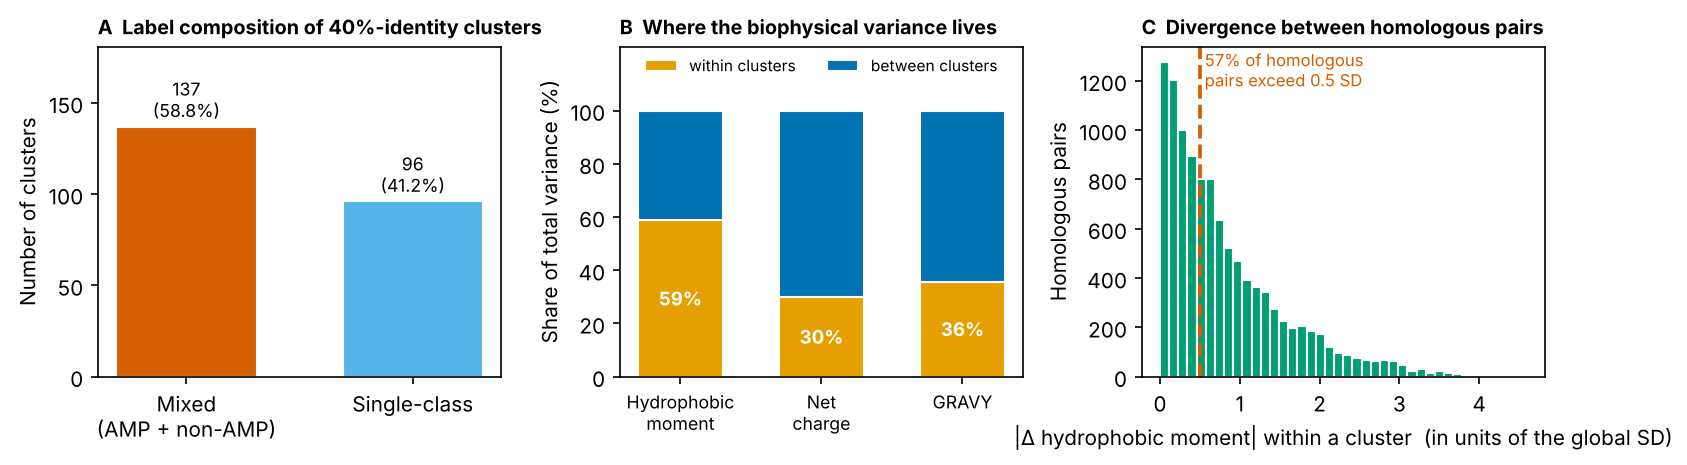

In [ ]:
print("=== Reviewer 2, comment 1: does 40% identity imply biophysical similarity? ===")

id2seq, cur = {}, None
for line in open(f"{DATA_DIR}/seqs.fasta"):
    line = line.strip()
    if line.startswith(">"): cur = line[1:].split()[0]
    elif cur: id2seq[cur] = id2seq.get(cur, "") + line
seq2idx = {s: i for i, s in enumerate(df.sequence)}

cluster_of, cid = {}, None
for line in open(f"{DATA_DIR}/clust.clstr"):
    if line.startswith(">Cluster"):
        cid = int(line.split()[1])
    else:
        m = re.search(r">([^.]+)\.\.\.", line)
        if m and cid is not None and id2seq.get(m.group(1)) in seq2idx:
            cluster_of[seq2idx[id2seq[m.group(1)]]] = cid

df["cluster"] = pd.Series(cluster_of)
multi = df.dropna(subset=["cluster"]).astype({"cluster": int})
multi = multi.groupby("cluster").filter(lambda g: len(g) >= 2)
gm = multi.groupby("cluster")
mixed = gm.label.nunique()
n_mixed, n_pure = int((mixed > 1).sum()), int((mixed == 1).sum())
print(f"multi-member clusters: {gm.ngroups} covering {len(multi)} sequences")
print(f"clusters holding BOTH AMP and non-AMP: {n_mixed} ({100*n_mixed/(n_mixed+n_pure):.1f}%)")

rows, within = [], []
for p, lbl in [("uH", "Hydrophobic moment"), ("charge", "Net charge"), ("gravy", "GRAVY")]:
    g = multi.groupby("cluster")[p]
    ssw = sum(((sub - sub.mean())**2).sum() for _, sub in g)
    pct = 100*ssw/((multi[p] - multi[p].mean())**2).sum()
    within.append(pct)
    rows.append([lbl, round(multi[p].std(ddof=0), 3), round(g.std(ddof=0).mean(), 3),
                 round(pct, 1), round(g.apply(lambda v: v.max()-v.min()).median(), 3)])
tableS3 = pd.DataFrame(rows, columns=["Descriptor", "Total SD", "Mean within-cluster SD",
                                      "Within-cluster variance (%)", "Median within-cluster range"])
print("\nTable S3"); print(tableS3.to_string(index=False))

tot = multi.uH.std(ddof=0)
diffs = np.array([abs(v[i]-v[j]) for _, sub in multi.groupby("cluster")
                  for v in [sub.uH.values] for i in range(len(v)) for j in range(i+1, len(v))])
print(f"\nhomologous pairs differing by >0.5 SD in uH: {100*(diffs > 0.5*tot).mean():.1f}%")

fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2), dpi=150)
ax[0].bar(["Mixed\n(AMP + non-AMP)", "Single-class"], [n_mixed, n_pure],
          color=[WONG["vermillion"], WONG["sky"]], edgecolor="white", width=.62)
for x, v in enumerate([n_mixed, n_pure]):
    ax[0].text(x, v+3, f"{v}\n({100*v/(n_mixed+n_pure):.1f}%)", ha="center", va="bottom", fontsize=8.5)
ax[0].set_ylabel("Number of clusters"); ax[0].set_ylim(0, max(n_mixed, n_pure)*1.32)
ax[0].set_title("A  Label composition of 40%-identity clusters", loc="left", fontsize=9.5, fontweight="bold")

x = np.arange(3)
ax[1].bar(x, within, color=WONG["orange"], edgecolor="white", width=.6, label="within clusters")
ax[1].bar(x, [100-w for w in within], bottom=within, color=WONG["blue"], edgecolor="white",
          width=.6, label="between clusters")
for i, w in enumerate(within):
    ax[1].text(i, w/2, f"{w:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(["Hydrophobic\nmoment", "Net\ncharge", "GRAVY"], fontsize=8.5)
ax[1].set_ylabel("Share of total variance (%)"); ax[1].set_ylim(0, 124)
ax[1].set_yticks([0, 20, 40, 60, 80, 100])
ax[1].legend(fontsize=7.5, loc="upper center", ncol=2, framealpha=0, borderpad=.1)
ax[1].set_title("B  Where the biophysical variance lives", loc="left", fontsize=9.5, fontweight="bold")

ax[2].hist(diffs/tot, bins=40, color=WONG["green"], edgecolor="white")
ax[2].axvline(0.5, color=WONG["vermillion"], lw=1.8, ls="--")
ax[2].text(0.56, ax[2].get_ylim()[1]*0.88,
           f"{100*(diffs > 0.5*tot).mean():.0f}% of homologous\npairs exceed 0.5 SD",
           color=WONG["vermillion"], fontsize=8)
ax[2].set_xlabel("|\u0394 hydrophobic moment| within a cluster  (in units of the global SD)")
ax[2].set_ylabel("Homologous pairs")
ax[2].set_title("C  Divergence between homologous pairs", loc="left", fontsize=9.5, fontweight="bold")
fig.tight_layout(); plt.show()


=== Reviewer 2, comment 2: why do two accurate oracles disagree on optimized sequences? ===
oracle A (physicochemical) held-out AUC: 0.933
oracle B (dipeptide)       held-out AUC: 0.949

Table S4
        Evaluation regime  Pearson r    n
       Natural full range      0.864  518
 Off-distribution mutants      0.405 1200
  Natural high-score band      0.119  195
Mutants + high-score band     -0.221  411

this work, multi-oracle objective: r = 0.545 (single oracle: 0.145)


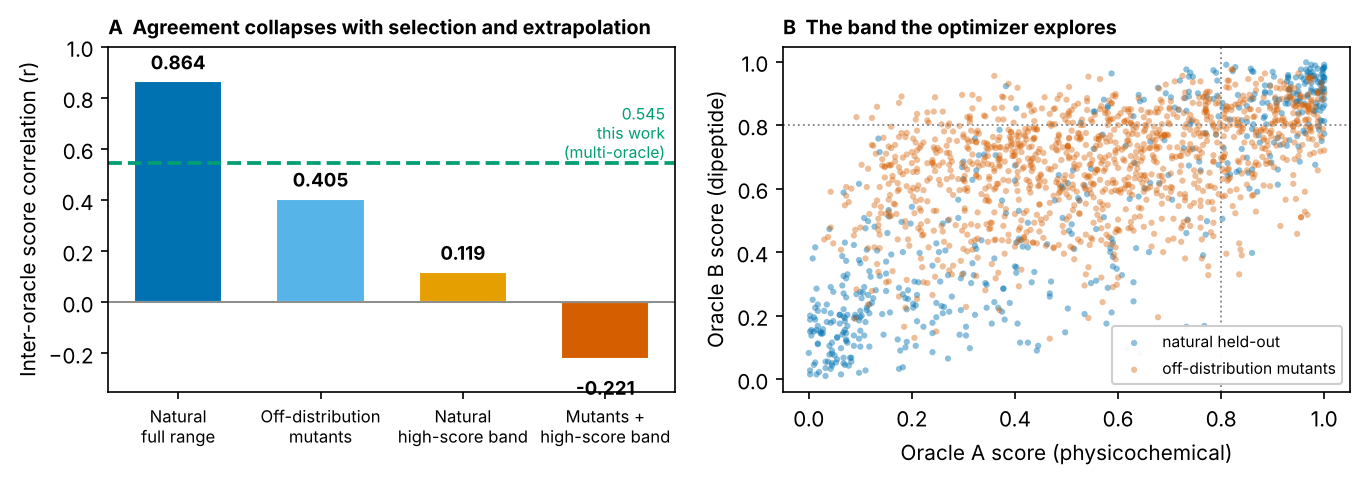

In [ ]:
print("=== Reviewer 2, comment 2: why do two accurate oracles disagree on optimized sequences? ===")

AA = "ACDEFGHIKLMNPQRSTVWY"
HBD = {"R":5,"K":3,"W":1,"N":2,"Q":2,"H":1,"S":1,"T":1,"Y":1,"C":1}
HBA = {"D":2,"E":2,"N":2,"Q":2,"S":1,"T":1,"Y":1,"H":1}
DIX = {a+b: i for i, (a, b) in enumerate((x, y) for x in AA for y in AA)}

def charge_simple(s):
    return sum(1 for a in s if a in "KR") - sum(1 for a in s if a in "DE")

def desc(s):
    L = len(s)
    return [L, gravy(s), uH(s), charge_simple(s), sum(1 for a in s if a in "KRDE")/L,
            sum(HBD.get(a, 0) for a in s)/L, sum(HBA.get(a, 0) for a in s)/L,
            sum(1 for a in s if a in "AVLIMFWC")/L, sum(1 for a in s if a in "FWY")/L]

def dipep(s):
    v = np.zeros(400)
    for i in range(len(s)-1):
        j = DIX.get(s[i:i+2])
        if j is not None: v[j] += 1
    return v/max(len(s)-1, 1)

rng = np.random.default_rng(0)
def mutate(s, n):
    s = list(s)
    for _ in range(n): s[rng.integers(len(s))] = AA[rng.integers(20)]
    return "".join(s)

seqs, y = df.sequence.tolist(), df.label.values
Xd, Xp = np.array([desc(s) for s in seqs]), np.array([dipep(s) for s in seqs])
tr, te = train_test_split(np.arange(len(seqs)), test_size=.3, stratify=y, random_state=0)
A = RandomForestClassifier(400, random_state=0, n_jobs=-1).fit(Xd[tr], y[tr])
B = RandomForestClassifier(400, random_state=1, n_jobs=-1).fit(Xp[tr], y[tr])
pa, pb = A.predict_proba(Xd[te])[:, 1], B.predict_proba(Xp[te])[:, 1]
print(f"oracle A (physicochemical) held-out AUC: {roc_auc_score(y[te], pa):.3f}")
print(f"oracle B (dipeptide)       held-out AUC: {roc_auc_score(y[te], pb):.3f}")

amps = [s for s, l in zip(seqs, y) if l == 1]
mut = [mutate(rng.choice(amps), k) for k in rng.integers(3, 12, 1200)]
ma = A.predict_proba(np.array([desc(s) for s in mut]))[:, 1]
mb = B.predict_proba(np.array([dipep(s) for s in mut]))[:, 1]
hi, hm = (pa > .8) | (pb > .8), (ma > .8) | (mb > .8)
rs = [pearsonr(pa, pb)[0], pearsonr(ma, mb)[0], pearsonr(pa[hi], pb[hi])[0], pearsonr(ma[hm], mb[hm])[0]]
ns = [len(te), len(mut), int(hi.sum()), int(hm.sum())]
names = ["Natural\nfull range", "Off-distribution\nmutants",
         "Natural\nhigh-score band", "Mutants +\nhigh-score band"]
tableS4 = pd.DataFrame({"Evaluation regime": [n.replace("\n", " ") for n in names],
                        "Pearson r": np.round(rs, 3), "n": ns})
print("\nTable S4"); print(tableS4.to_string(index=False))
print("\nthis work, multi-oracle objective: r = 0.545 (single oracle: 0.145)")

fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.3), dpi=150)
cols = [WONG["blue"], WONG["sky"], WONG["orange"], WONG["vermillion"]]
ax[0].bar(np.arange(4), rs, color=cols, edgecolor="white", width=.62)
for i, r in enumerate(rs):
    ax[0].text(i, r + (.03 if r >= 0 else -.07), f"{r:.3f}", ha="center",
               va="bottom" if r >= 0 else "top", fontsize=9, fontweight="bold")
ax[0].axhline(0, color="#888888", lw=.9)
ax[0].axhline(0.545, color=WONG["green"], lw=1.8, ls="--")
ax[0].text(3.42, 0.565, "0.545\nthis work\n(multi-oracle)", color=WONG["green"], fontsize=7.6, ha="right")
ax[0].set_xticks(np.arange(4)); ax[0].set_xticklabels(names, fontsize=8)
ax[0].set_ylabel("Inter-oracle score correlation (r)"); ax[0].set_ylim(-.35, 1.0)
ax[0].set_title("A  Agreement collapses with selection and extrapolation",
                loc="left", fontsize=9.5, fontweight="bold")

ax[1].scatter(pa, pb, s=9, color=WONG["blue"], alpha=.45, label="natural held-out", edgecolor="none")
ax[1].scatter(ma, mb, s=9, color=WONG["vermillion"], alpha=.40, label="off-distribution mutants", edgecolor="none")
ax[1].axvline(.8, color="#888888", lw=.9, ls=":"); ax[1].axhline(.8, color="#888888", lw=.9, ls=":")
ax[1].set_xlabel("Oracle A score (physicochemical)"); ax[1].set_ylabel("Oracle B score (dipeptide)")
ax[1].legend(fontsize=7.5, loc="lower right", framealpha=.95)
ax[1].set_title("B  The band the optimizer explores", loc="left", fontsize=9.5, fontweight="bold")
fig.tight_layout(); plt.show()
